# Confrontation des deux datasets

**Objectif** : comparer les deux jeux de données sur ce qu'ils ont en commun, pour décider du
rôle de chacun dans la suite du projet.

- `data/agriculture-crop-yield/crop_yield.csv` — une ligne = une parcelle sur une saison.
- `data/processed/crop_yield_prediction_1990_2013.csv` — une ligne = pays × année × culture.

Ce notebook ne refait pas l'exploration de chaque source : elle est faite dans les notebooks
01 à 04. Il ne garde que les variables présentes des deux côtés.

## Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from agritech import utils
from agritech.config import AGRICULTURE_CROP_YIELD_FILENAME, PATHS, SEED

## Lecture des datasets

In [2]:
DEBUT, FIN = 1990, 2013
df_fusion = pd.read_csv(PATHS.data_processed / f"crop_yield_prediction_{DEBUT}_{FIN}.csv")

In [3]:
csv_path = PATHS.data_agriculture_crop_yield / AGRICULTURE_CROP_YIELD_FILENAME
df_agri = pd.read_csv(csv_path)

## Vue d'ensemble

In [4]:
print("Taille (lignes x colonnes)")
print("  - fusion :", df_fusion.shape)
print("  - agri   :", df_agri.shape)

print("\nGranularité")
print("  - fusion : pays x année x culture")
print("  - agri   : une parcelle sur une saison")

print("\nPériode")
print(f"  - fusion : {df_fusion.year.min()} - {df_fusion.year.max()}")
print("  - agri   : aucune colonne de temps")

print("\nCible")
print(f"  - fusion : yield_t_ha, {df_fusion.yield_t_ha.min():.2f} - {df_fusion.yield_t_ha.max():.2f} t/ha")
print(f"  - agri   : Yield_tons_per_hectare, {df_agri.Yield_tons_per_hectare.min():.2f} - "
      f"{df_agri.Yield_tons_per_hectare.max():.2f} t/ha")

print("\nColonnes")
print("  - fusion :", df_fusion.columns.tolist())
print("  - agri   :", df_agri.columns.tolist())

Taille (lignes x colonnes)
  - fusion : (22679, 8)
  - agri   : (1000000, 10)

Granularité
  - fusion : pays x année x culture
  - agri   : une parcelle sur une saison

Période
  - fusion : 1990 - 2013
  - agri   : aucune colonne de temps

Cible
  - fusion : yield_t_ha, 0.00 - 55.49 t/ha
  - agri   : Yield_tons_per_hectare, -1.15 - 9.96 t/ha

Colonnes
  - fusion : ['iso3', 'area', 'year', 'crop', 'yield_t_ha', 'avg_temp', 'rain_mm', 'pesticides_t']
  - agri   : ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']


**Observations :**

- Les deux jeux n'ont pas la même unité d'observation : une parcelle d'un côté, un couple
  pays × année × culture de l'autre.
- Rapport de taille de 1 à 44 en nombre de lignes.
- Seule la fusion porte une dimension temporelle : aucune comparaison année par année n'est
  possible.

## Variables comparables

In [5]:
print("Rendement")
print(f"  - fusion : {df_fusion.yield_t_ha.min():.2f} - {df_fusion.yield_t_ha.max():.2f} (yield_t_ha)")
print(f"  - agri   : {df_agri.Yield_tons_per_hectare.min():.2f} - "
      f"{df_agri.Yield_tons_per_hectare.max():.2f} (Yield_tons_per_hectare)")

print("\nTempérature")
print(f"  - fusion : {df_fusion.avg_temp.min():.2f} - {df_fusion.avg_temp.max():.2f} (avg_temp)")
print(f"  - agri   : {df_agri.Temperature_Celsius.min():.2f} - "
      f"{df_agri.Temperature_Celsius.max():.2f} (Temperature_Celsius)")

print("\nPluie")
print(f"  - fusion : {df_fusion.rain_mm.min():.0f} - {df_fusion.rain_mm.max():.0f} (rain_mm)")
print(f"  - agri   : {df_agri.Rainfall_mm.min():.0f} - {df_agri.Rainfall_mm.max():.0f} (Rainfall_mm)")

print("\nCultures")
print("  - fusion :", sorted(df_fusion.crop.unique()))
print("  - agri   :", sorted(df_agri.Crop.unique()))

Rendement
  - fusion : 0.00 - 55.49 (yield_t_ha)
  - agri   : -1.15 - 9.96 (Yield_tons_per_hectare)

Température
  - fusion : -3.37 - 30.42 (avg_temp)
  - agri   : 15.00 - 40.00 (Temperature_Celsius)

Pluie
  - fusion : 51 - 3240 (rain_mm)
  - agri   : 100 - 1000 (Rainfall_mm)

Cultures
  - fusion : ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']
  - agri   : ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']


**Observations :**

- Trois variables sont comparables : **rendement**, **température**, **pluie**. Elles portent
  la même unité de part et d'autre.
- Elles n'ont pas pour autant la même définition : `rain_mm` est une normale climatique par
  pays, constante sur les 24 années (notebook 03), alors que `Rainfall_mm` est la pluie tombée
  sur une saison.
- Les listes de cultures se recoupent partiellement, à deux écritures près.

### Variables non comparables

In [6]:
print("Localisation")
print("  - fusion (area)   :", df_fusion.area.unique().tolist()[:5], "...")
print("  - agri   (Region) :", df_agri.Region.unique().tolist())

print("\nIntrants")
print(f"  - fusion : pesticides_t, {df_fusion.pesticides_t.min():.0f} - "
      f"{df_fusion.pesticides_t.max():.0f} tonnes déclarées par pays et par année")
print("  - agri   : Fertilizer_Used, Irrigation_Used, deux booléens à l'échelle de la parcelle")

Localisation
  - fusion (area)   : ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina'] ...
  - agri   (Region) : ['West', 'South', 'North', 'East']

Intrants
  - fusion : pesticides_t, 0 - 1806000 tonnes déclarées par pays et par année
  - agri   : Fertilizer_Used, Irrigation_Used, deux booléens à l'échelle de la parcelle


**Observations :**

- `area` désigne un pays, `Region` un quadrant (North, East, South, West) sans pays associé :
  aucun rapprochement géographique n'est possible.
- `pesticides_t` est un tonnage national ; `Fertilizer_Used` et `Irrigation_Used` sont des
  pratiques déclarées sur une parcelle. Ni la même échelle, ni le même intrant : ces variables
  ne sont pas mises en correspondance.

Colonnes d'Agriculture CropYield sans équivalent dans la fusion :

| Colonne | Type | Ce que c'est |
|---|---|---|
| `Soil_Type` | texte | Type de sol : Sandy, Clay, Loam, Silt, Peaty, Chalky |
| `Fertilizer_Used` | booléen | Engrais utilisé ou non |
| `Irrigation_Used` | booléen | Irrigation utilisée ou non |
| `Weather_Condition` | texte | Météo dominante : Sunny, Rainy, Cloudy |
| `Days_to_Harvest` | entier | Nombre de jours avant la récolte |

## Cultures communes

Deux libellés diffèrent seulement par leur écriture : `Rice, paddy` côté fusion pour `Rice`
côté Agriculture CropYield, et `Soybeans` pour `Soybean`. Ils sont ramenés à l'écriture du
second jeu, la plus courte.

In [7]:
df_fusion["crop"] = df_fusion["crop"].replace({"Rice, paddy": "Rice", "Soybeans": "Soybean"})

cultures_fusion = set(df_fusion.crop.unique())
cultures_agri = set(df_agri.Crop.unique())

COMMUNES = sorted(cultures_fusion & cultures_agri)

print("Communes                :", COMMUNES)
print("Seulement dans la fusion:", sorted(cultures_fusion - cultures_agri))
print("Seulement dans agri     :", sorted(cultures_agri - cultures_fusion))

Communes                : ['Maize', 'Rice', 'Soybean', 'Wheat']
Seulement dans la fusion: ['Cassava', 'Plantains and others', 'Potatoes', 'Sorghum', 'Sweet potatoes', 'Yams']
Seulement dans agri     : ['Barley', 'Cotton']


**Observations :**

- Quatre cultures communes : `Maize`, `Rice`, `Soybean`, `Wheat`.
- Six cultures ne sont que dans la fusion, dont les tubercules ; deux ne sont que dans
  Agriculture CropYield.
- La suite de la comparaison est restreinte à ces quatre cultures.

In [8]:
fusion_communes = df_fusion.query("crop in @COMMUNES")
agri_communes = df_agri.query("Crop in @COMMUNES")

print(f"fusion : {len(fusion_communes)} lignes, {fusion_communes.iso3.nunique()} pays")
print(f"agri   : {len(agri_communes)} lignes")
print("\nvaleurs manquantes de la fusion (%) :")
print((fusion_communes.isna().mean() * 100).round(1).to_string())

fusion : 11044 lignes, 166 pays
agri   : 666638 lignes

valeurs manquantes de la fusion (%) :
iso3             0.0
area             0.0
year             0.0
crop             0.0
yield_t_ha       0.0
avg_temp        17.3
rain_mm          4.6
pesticides_t    11.9


**Observations :**

- 11 044 lignes côté fusion pour 166 pays, contre 666 638 côté Agriculture CropYield.
- La fusion garde ses manquants : température 17,3 %, pesticides 11,9 %, pluie 4,6 %. Les
  calculs qui suivent portent sur les valeurs disponibles.

## Comparaison des distributions

Les trois variables comparables sont tracées de la même façon : un boxplot par culture, une
couleur par jeu de données.

In [9]:
DATASETS = ["Fusion historique", "Agriculture CropYield"]

# libellé affiché -> (colonne de la fusion, colonne d'Agriculture CropYield)
VARIABLES = {
    "rendement (t/ha)": ("yield_t_ha", "Yield_tons_per_hectare"),
    "température (°C)": ("avg_temp", "Temperature_Celsius"),
    "pluie (mm)": ("rain_mm", "Rainfall_mm"),
}


def empile(libelle):
    """Empile les deux jeux sur une variable comparable, une ligne par observation."""
    col_fusion, col_agri = VARIABLES[libelle]

    fusion = (
        fusion_communes[["crop", col_fusion]]
        .rename(columns={col_fusion: libelle})
        .assign(dataset=DATASETS[0])
    )
    agri = (
        agri_communes[["Crop", col_agri]]
        .rename(columns={"Crop": "crop", col_agri: libelle})
        .assign(dataset=DATASETS[1])
    )
    return pd.concat([fusion, agri], ignore_index=True)


def boxplot_compare(libelle):
    """Compare la distribution d'une variable, par culture et par jeu de données."""
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=empile(libelle),
        x="crop",
        y=libelle,
        hue="dataset",
        order=COMMUNES,
        hue_order=DATASETS,
    )
    plt.xlabel("Culture")
    plt.ylabel(libelle)
    plt.title(f"Distribution — {libelle}")
    plt.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### Rendement par culture

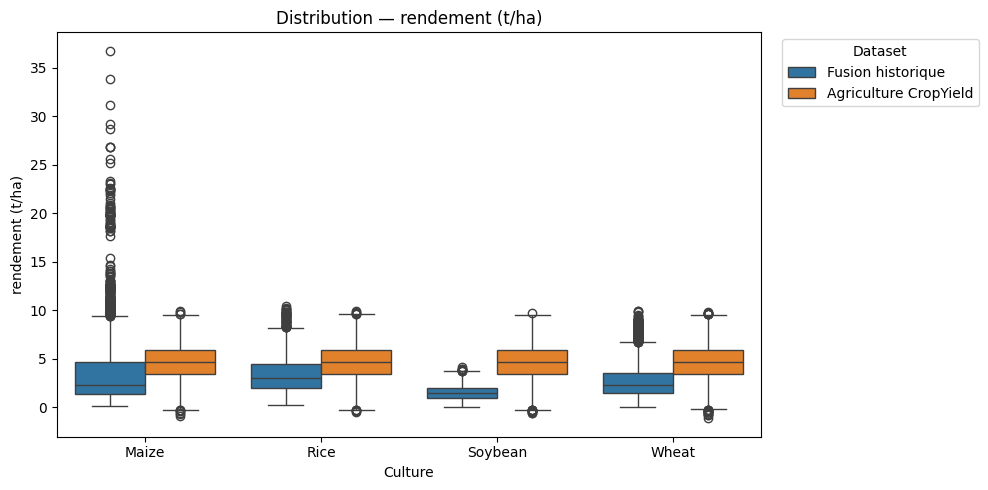

In [10]:
boxplot_compare("rendement (t/ha)")

**Observations :**

- Les quatre boîtes d'Agriculture CropYield sont superposées : même médiane, même étalement
  d'une culture à l'autre.
- Côté fusion, les niveaux se distinguent nettement, et les boîtes sont plus basses et plus
  étalées vers le haut.

### Température par culture

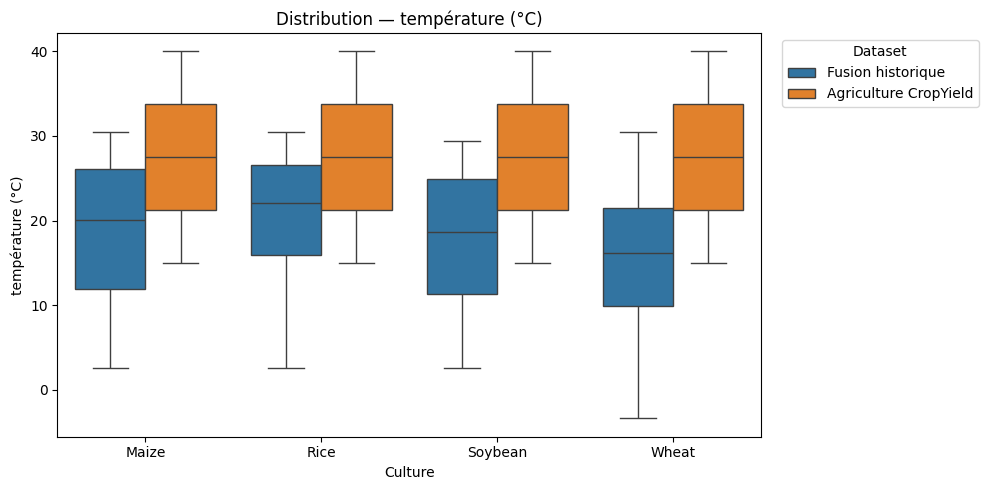

In [11]:
boxplot_compare("température (°C)")

**Observations :**

- Même constat côté Agriculture CropYield : les quatre boîtes sont identiques et couvrent
  toute la plage 15-40 °C.
- La fusion est décalée vers le bas : elle descend sous 0 °C pour le blé et plafonne à 30 °C.
- Les cultures s'y ordonnent, du blé (médiane 16,2 °C) au riz (22,0 °C).

### Pluie par culture

`rain_mm` est une normale climatique par pays, répétée à l'identique sur les 24 années
(notebook 03). Elle décrit le climat d'un pays, pas la pluie reçue par une parcelle sur une
saison comme `Rainfall_mm`. Les deux boîtes se lisent donc en gardant cette différence de
nature en tête.

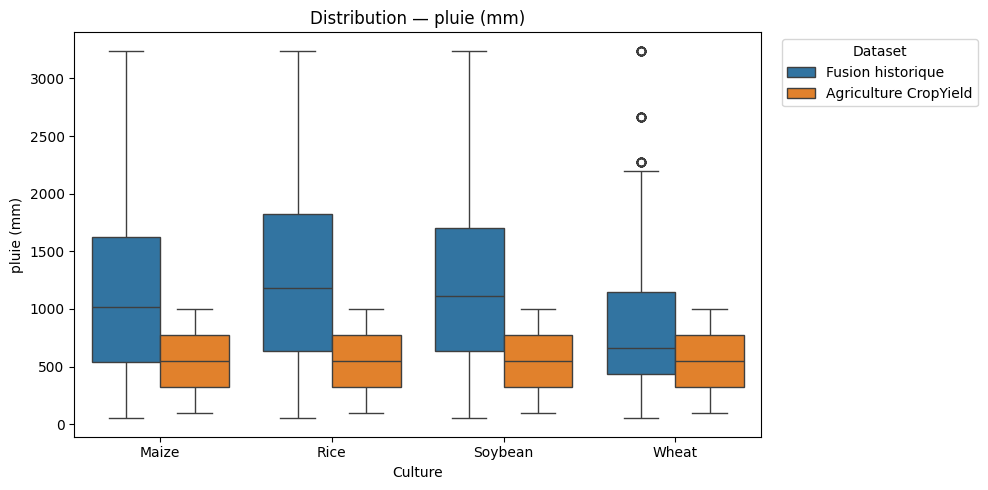

In [12]:
boxplot_compare("pluie (mm)")

**Observations :**

- La fusion couvre une plage bien plus large et déborde largement au-dessus de 1 000 mm,
  borne haute d'Agriculture CropYield.
- Les cultures s'ordonnent également côté fusion, le blé étant la plus sèche.
- La comparaison reste indicative : les deux variables ne mesurent pas la même chose.

## Synthèse chiffrée des cultures communes

Médiane, moyenne et écart-type des trois variables comparables, pour chaque culture et chaque
jeu de données.

In [13]:
def stats_par_culture(df, colonne_culture, colonnes):
    """Médiane, moyenne et écart-type par culture, pour chaque variable comparable."""
    tables = {}
    for libelle, colonne in colonnes.items():
        tables[libelle] = df.groupby(colonne_culture)[colonne].agg(["median", "mean", "std"])
    return pd.concat(tables, names=["variable", "culture"])


synthese = pd.concat(
    {
        DATASETS[0]: stats_par_culture(
            fusion_communes, "crop", {k: v[0] for k, v in VARIABLES.items()}
        ),
        DATASETS[1]: stats_par_culture(
            agri_communes, "Crop", {k: v[1] for k, v in VARIABLES.items()}
        ),
    },
    axis=1,
).rename(columns={"median": "médiane", "mean": "moyenne", "std": "écart-type"})

synthese.round(2)

Fusion historique                      \
                                   médiane  moyenne écart-type   
variable         culture                                         
rendement (t/ha) Maize                2.33     3.70       3.77   
                 Rice                 3.06     3.43       1.89   
                 Soybean              1.45     1.53       0.76   
                 Wheat                2.30     2.79       1.87   
température (°C) Maize               20.07    19.12       7.10   
                 Rice                22.04    20.76       6.46   
                 Soybean             18.64    18.19       6.89   
                 Wheat               16.17    16.15       7.15   
pluie (mm)       Maize             1020.00  1105.80     760.09   
                 Rice              1181.00  1305.68     800.00   
                 Soybean           1110.00  1200.38     687.82   
                 Wheat              661.00   847.53     603.85   

                         Agriculture CropYield                     
                                       médiane moyenne écart-type  
variable         culture                                           
rendement (t/ha) Maize                    4.64    4.64       1.70  
                 Rice                     4.65    4.65       1.70  
                 Soybean                  4.66    4.65       1.70  
                 Wheat                    4.66    4.65       1.69  
température (°C) Maize                   27.47   27.48       7.22  
                 Rice                    27.53   27.50       7.20  
                 Soybean                 27.50   27.51       7.23  
                 Wheat                   27.51   27.52       7.22  
pluie (mm)       Maize                  549.67  549.20     259.90  
                 Rice                   550.40  550.51     259.84  
                 Soybean                551.69  550.47     259.60  
                 Wheat                  550.47  550.25     259.77

**Observations :**

- Agriculture CropYield : les quatre cultures sont interchangeables sur les trois variables —
  rendement médian 4,64 à 4,66 t/ha, température 27,5 °C, pluie 550 mm.
- Fusion : les médianes de rendement vont de 1,45 t/ha (soja) à 3,06 t/ha (riz), soit un
  facteur 2, et les conditions diffèrent aussi (blé 16,2 °C et 661 mm, riz 22,0 °C et
  1 181 mm).
- Côté fusion, moyenne et médiane s'écartent nettement pour le maïs (3,70 contre 2,33) :
  distribution asymétrique, tirée par quelques rendements très élevés.

## Température × pluie par culture

Les cultures occupent-elles des zones différentes selon la température et la pluie ? Les deux
jeux sont tracés séparément mais sur les mêmes axes, sur un échantillon reproductible de
4 000 points chacun : un million de points saturerait la figure.

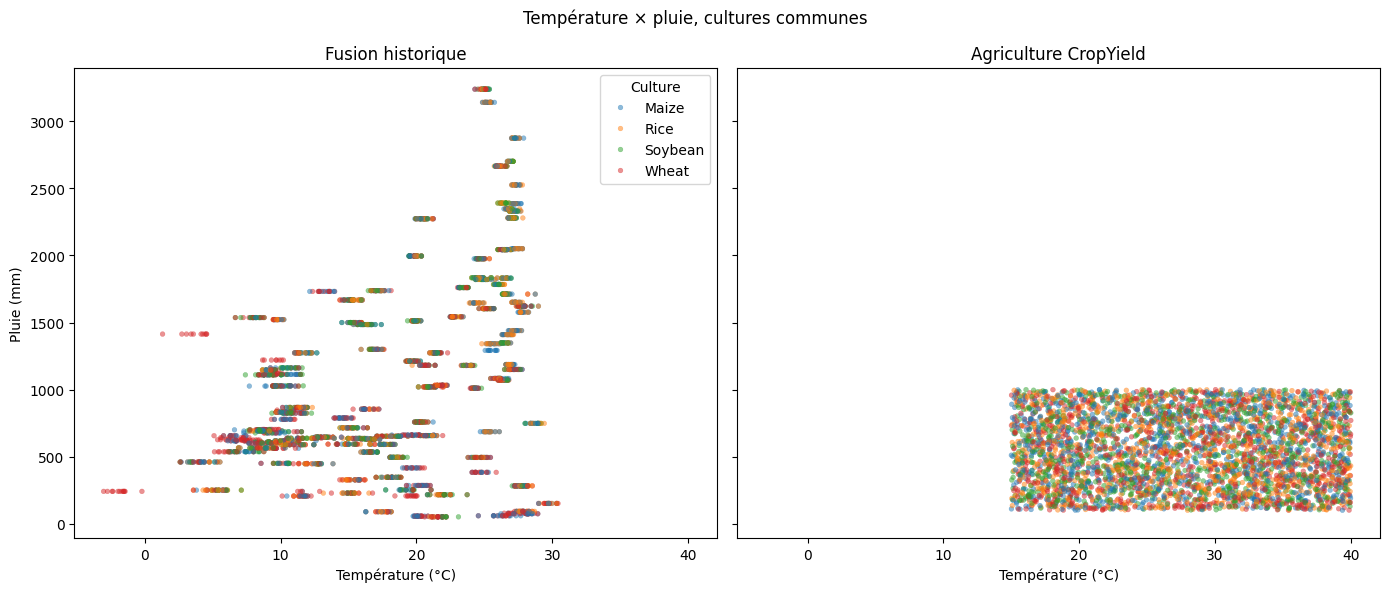

In [14]:
TAILLE_ECHANTILLON = 4_000

fusion_climat = fusion_communes.dropna(subset=["avg_temp", "rain_mm"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=fusion_climat.sample(TAILLE_ECHANTILLON, random_state=SEED),
    x="avg_temp", y="rain_mm", hue="crop", hue_order=COMMUNES,
    s=12, alpha=0.5, edgecolor=None, ax=axes[0],
)
axes[0].set_title(DATASETS[0])
axes[0].legend(title="Culture", loc="upper right")

sns.scatterplot(
    data=agri_communes.sample(TAILLE_ECHANTILLON, random_state=SEED),
    x="Temperature_Celsius", y="Rainfall_mm", hue="Crop", hue_order=COMMUNES,
    s=12, alpha=0.5, edgecolor=None, ax=axes[1],
)
axes[1].set_title(DATASETS[1])
axes[1].get_legend().remove()

for ax in axes:
    ax.set_xlabel("Température (°C)")
    ax.set_ylabel("Pluie (mm)")

fig.suptitle("Température × pluie, cultures communes")
fig.tight_layout()
plt.show()

**Observations :**

- Les deux nuages n'occupent pas la même zone : Agriculture CropYield forme un rectangle plein
  entre 15 et 40 °C et 100 et 1 000 mm, la fusion s'étale de −3 à 30 °C et jusqu'à 3 240 mm. Le
  recouvrement se limite à un coin du plan.
- Agriculture CropYield : les quatre couleurs sont mélangées uniformément, sans zone propre à
  une culture. Pluie et température y sont aussi indépendantes l'une de l'autre (notebook 02).
- Fusion : les points s'alignent en bandes horizontales, `rain_mm` ne prenant qu'une seule
  valeur par pays. Le blé apparaît un peu plus à gauche et le riz un peu plus à droite, mais les
  quatre couleurs se recouvrent sur presque toute la surface : aucune culture n'occupe de zone
  qui lui soit propre.

## Relations avec le rendement

Corrélations de Pearson entre le rendement et les variables disponibles, sur les cultures
communes. `pesticides_t` n'a pas d'équivalent dans Agriculture CropYield et n'est donc mis en
correspondance avec aucune de ses colonnes.

In [15]:
corr_fusion = fusion_communes[["avg_temp", "rain_mm", "pesticides_t"]].corrwith(
    fusion_communes["yield_t_ha"]
)
corr_agri = agri_communes[["Temperature_Celsius", "Rainfall_mm"]].corrwith(
    agri_communes["Yield_tons_per_hectare"]
)

pd.DataFrame(
    {
        DATASETS[0]: corr_fusion.rename(
            {"avg_temp": "température", "rain_mm": "pluie", "pesticides_t": "pesticides"}
        ),
        DATASETS[1]: corr_agri.rename(
            {"Temperature_Celsius": "température", "Rainfall_mm": "pluie"}
        ),
    }
).reindex(["température", "pluie", "pesticides"]).round(3)

,Fusion historique,Agriculture CropYield
température,-0.267,0.085
pluie,-0.161,0.764
pesticides,0.094,NaN


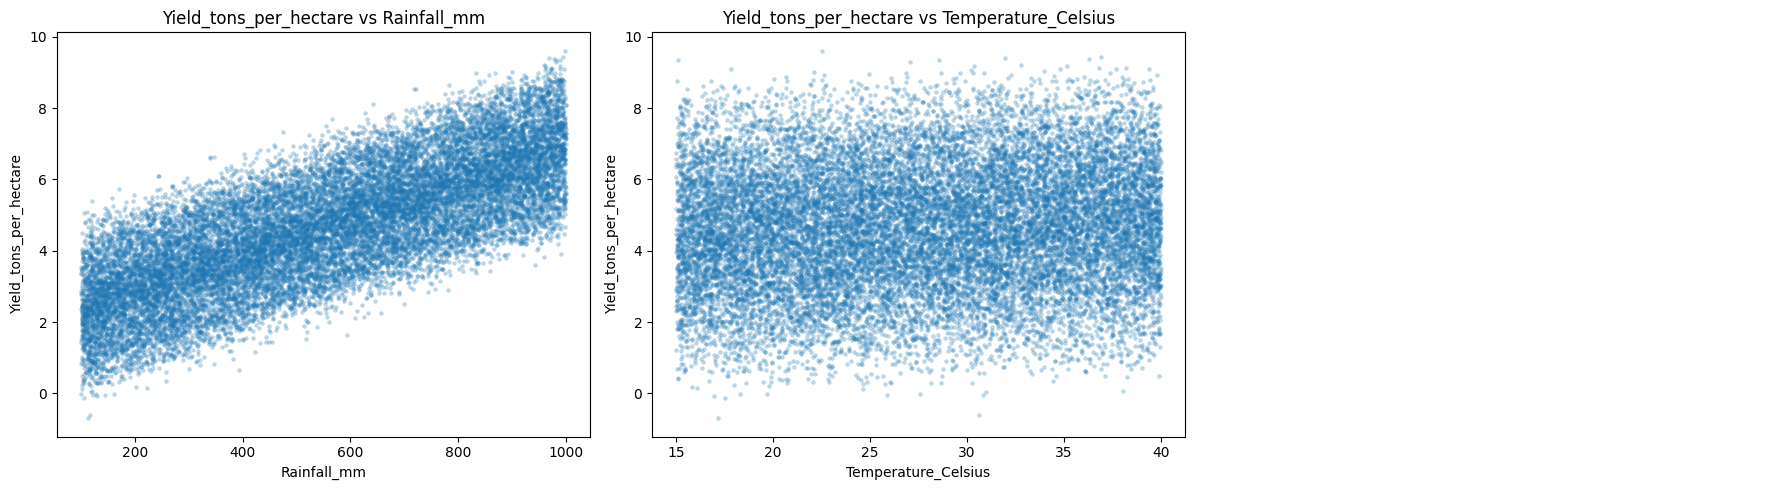

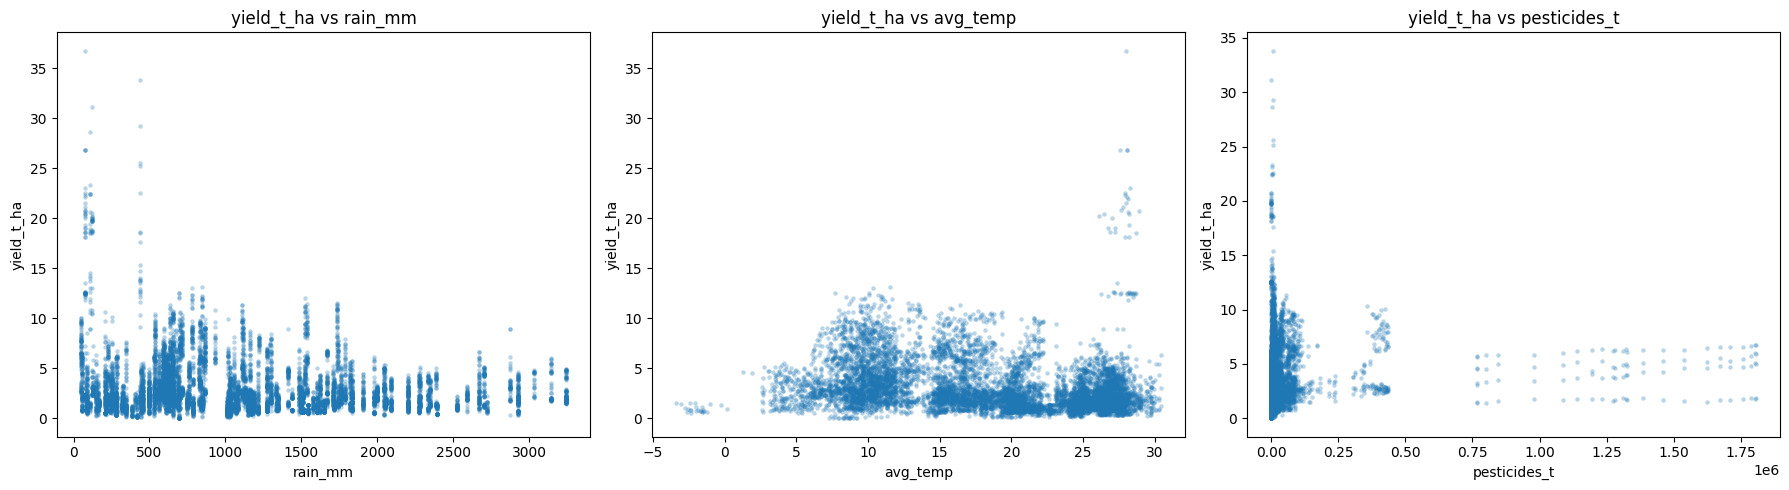

In [16]:
utils.plot_pairs(
    agri_communes,
    "Yield_tons_per_hectare",
    ["Rainfall_mm", "Temperature_Celsius"],
)
utils.plot_pairs(
    fusion_communes,
    "yield_t_ha",
    ["rain_mm", "avg_temp", "pesticides_t"],
)

**Observations :**

- Les deux corrélations comparables changent de signe d'un jeu à l'autre : pluie +0,764 contre
  −0,161, température +0,085 contre −0,267.
- Côté Agriculture CropYield, la relation pluie / rendement est droite et de largeur constante ;
  côté fusion, le nuage n'a pas de forme nette.
- Ces corrélations ne se lisent pas de la même façon : dans la fusion, une ligne est un pays et
  une année, et `rain_mm` comme `avg_temp` décrivent le climat moyen du pays. Le signe négatif
  reflète surtout les écarts de rendement entre pays, pas un effet de la pluie sur une parcelle.
- `pesticides_t` est faiblement corrélé au rendement (0,094) et sans équivalent en face : il
  n'entre pas dans la comparaison.

## Dispersion des variables communes

Plage et dispersion des trois variables comparables, sur les cultures communes.

In [17]:
def dispersion(serie):
    """Plage et dispersion d'une variable, valeurs manquantes ignorées."""
    q1, q3 = serie.quantile([0.25, 0.75])
    return pd.Series(
        {
            "min": serie.min(),
            "max": serie.max(),
            "étendue": serie.max() - serie.min(),
            "médiane": serie.median(),
            "écart-type": serie.std(),
            "IQR": q3 - q1,
        }
    )


lignes = {}
for libelle, (col_fusion, col_agri) in VARIABLES.items():
    lignes[(libelle, DATASETS[0])] = dispersion(fusion_communes[col_fusion])
    lignes[(libelle, DATASETS[1])] = dispersion(agri_communes[col_agri])

pd.DataFrame(lignes).T.round(2)

min      max  étendue  médiane  \
rendement (t/ha) Fusion historique        0.00    36.76    36.76     2.22   
                 Agriculture CropYield   -1.15     9.96    11.11     4.65   
température (°C) Fusion historique       -3.37    30.42    33.79    19.54   
                 Agriculture CropYield   15.00    40.00    25.00    27.50   
pluie (mm)       Fusion historique       51.00  3240.00  3189.00  1020.00   
                 Agriculture CropYield  100.01  1000.00   899.99   550.61   

                                        écart-type      IQR  
rendement (t/ha) Fusion historique            2.64     2.36  
                 Agriculture CropYield        1.70     2.46  
température (°C) Fusion historique            7.13    13.82  
                 Agriculture CropYield        7.22    12.49  
pluie (mm)       Fusion historique          739.40  1039.00  
                 Agriculture CropYield      259.78   449.46

**Observations :**

- Rendement : la fusion s'étend sur 36,8 t/ha contre 11,1, soit trois fois plus, alors que son
  IQR est légèrement plus faible (2,36 contre 2,46). L'écart vient des valeurs hautes, pas du
  cœur de la distribution.
- Température : la fusion descend à −3,4 °C, Agriculture CropYield s'arrête à 15 °C et monte à
  40 °C. Les deux plages ne se recouvrent qu'entre 15 et 30 °C.
- Pluie : 51 à 3 240 mm contre 100 à 1 000 mm, soit une étendue 3,5 fois plus large côté
  fusion, avec un IQR plus de deux fois supérieur.
- Le constat visuel est confirmé : la fusion couvre des conditions bien plus variées, mais
  seule une partie de cette plage est commune aux deux jeux.

## Ce que le dataset historique confirme ou non

- **Ordres de grandeur** : les rendements d'Agriculture CropYield (médianes 4,64 à 4,66 t/ha)
  restent dans la plage observée dans la fusion sur ces quatre cultures, mais au-dessus de
  toutes ses médianes (1,45 à 3,06 t/ha). Plausibles, donc, sans être typiques.
- **Distributions** : elles ne se superposent pas. Le rendement synthétique est symétrique et
  resserré, l'historique asymétrique et trois fois plus étalé ; la température synthétique est
  bornée à 15-40 °C quand l'historique descend à −3,4 °C ; la pluie synthétique s'arrête à
  1 000 mm quand l'historique va jusqu'à 3 240 mm.
- **Sens des relations** : les deux corrélations comparables sont de signes opposés. Côté
  fusion, elles décrivent surtout des écarts entre pays, et `rain_mm` y est une normale
  climatique : elles ne peuvent ni confirmer ni infirmer les relations mesurées à l'échelle
  d'une parcelle.
- **Limites** : unités d'observation différentes, variables de même nom mais de définitions
  différentes, aucune période commune et quatre cultures partagées sur dix et six. La fusion ne
  peut donc pas servir de référence pour valider Agriculture CropYield ; elle permet seulement
  de situer ses ordres de grandeur.

## Capacité à différencier les cultures

Deux questions distinctes : les cultures ont-elles des rendements différents, et peut-on
choisir une culture pour des conditions données ? Le rendement moyen par bande de température
permet de traiter la seconde. Les bandes retenues, 15 à 30 °C, sont la plage commune aux deux
jeux.

In [18]:
BANDES = [15, 20, 25, 30]


def rendement_par_bande(df, colonne_temp, colonne_culture, colonne_rendement):
    """Rendement moyen par bande de température et par culture, avec l'écart entre cultures."""
    bandes = pd.cut(df[colonne_temp], BANDES)
    table = df.pivot_table(
        index=bandes, columns=colonne_culture, values=colonne_rendement, observed=True
    )
    table["écart max"] = table.max(axis=1) - table.min(axis=1)
    return table.round(2)


print(DATASETS[0])
print(rendement_par_bande(fusion_communes, "avg_temp", "crop", "yield_t_ha"), "\n")
print(DATASETS[1])
print(rendement_par_bande(agri_communes, "Temperature_Celsius", "Crop", "Yield_tons_per_hectare"))

Fusion historique
crop      Maize  Rice  Soybean  Wheat  écart max
avg_temp                                        
(15, 20]   3.73  4.98     1.69   2.08       3.29
(20, 25]   1.94  2.80     1.41   2.31       1.39
(25, 30]   2.84  2.94     1.26   2.07       1.68 

Agriculture CropYield
Crop                 Maize  Rice  Soybean  Wheat  écart max
Temperature_Celsius                                        
(15, 20]              4.44  4.45     4.45   4.46       0.01
(20, 25]              4.53  4.55     4.56   4.56       0.03
(25, 30]              4.65  4.66     4.64   4.66       0.02


**Agriculture CropYield**

- À température comparable, l'écart de rendement moyen entre les quatre cultures reste de 0,01
  à 0,03 t/ha, soit moins de 1 %. L'EDA (0,012 t/ha entre modalités de `Crop`) et l'ACP (aucune
  séparation des cultures sur les plans examinés) donnaient déjà ce résultat.
- Le plan température × pluie confirme : les couleurs se mélangent, aucune culture n'occupe de
  zone propre.
- Ce jeu permet donc d'estimer un rendement à partir de conditions de parcelle, mais pas de
  départager les cultures.

**Fusion historique**

- Les cultures se distinguent par leur niveau : médianes de 1,45 t/ha (soja) à 3,06 t/ha (riz)
  sur les quatre communes, et jusqu'à 15,2 t/ha (pomme de terre) sur les dix.
- À température comparable, l'écart entre cultures reste de 1,4 à 3,3 t/ha, et l'ordre entre
  maïs et blé s'inverse entre 15-20 °C et 20-25 °C. Ce n'est donc pas seulement un effet de
  niveau global.
- Mais les nuages température × pluie se recouvrent largement, et les variables disponibles
  décrivent le climat moyen d'un pays. Ce qui différencie les cultures tient donc pour une
  large part à l'endroit où elles sont cultivées.
- Un classement des cultures est envisageable, à l'échelle d'un contexte climatique de pays,
  pas d'une parcelle.

## Stratégies possibles

**A. Fusionner directement les deux jeux**

Écartée. Trois variables communes seulement, dont une de définition différente, quatre cultures
partagées, des unités d'observation incompatibles (parcelle contre pays × année) et des plages
qui ne se recouvrent que partiellement. Empiler les lignes reviendrait à mélanger deux
populations distinctes, et les corrélations de signes opposés se retrouveraient dans le même
modèle. Les résultats confirment cet a priori plus qu'ils ne le nuancent.

**B. Utiliser uniquement Agriculture CropYield**

- Avantages : 1 000 000 de lignes, aucune valeur manquante, des variables qu'un utilisateur
  peut renseigner pour sa parcelle (pluie, température, engrais, irrigation, sol), et une
  relation forte et régulière avec le rendement (pluie 0,764).
- Limites : la culture n'a aucun effet, même à conditions comparables. `/predict` est
  réalisable, `/recommend` ne l'est pas.

**C. Utiliser uniquement la fusion historique**

- Avantages : données réelles, dix cultures nettement différenciées, profondeur temporelle.
- Limites : 22 679 lignes, 17,3 % de températures manquantes sur les cultures communes, des
  variables qui décrivent un pays et non une parcelle, et aucune pratique agricole. Un
  utilisateur ne peut pas renseigner le tonnage de pesticides de son pays. `/predict` à
  l'échelle d'une parcelle n'est pas soutenu.

**D. Utiliser les deux avec des rôles complémentaires**

Chaque jeu couvre ce qui manque à l'autre : des conditions de parcelle sans effet culture d'un
côté, un effet culture sans conditions de parcelle de l'autre. Deux modèles indépendants,
chacun entraîné sur son jeu, sans jamais empiler les lignes. Le coût est d'assumer deux
échelles différentes et de le dire dans l'interface. C'est la seule option qui couvre les deux
services.

## Stratégie retenue

**Option D**, avec un périmètre explicite pour chaque service.

- **Agriculture CropYield → `/predict`.** Régression du rendement à partir des conditions de
  parcelle : pluie, température, engrais, irrigation, et les variables catégorielles à trancher
  lors de la préparation. La culture n'apporte rien dans ce jeu : l'estimation retournée décrit
  les conditions et les pratiques, pas la culture semée. Ce point doit apparaître dans la
  réponse du service.
- **Fusion historique → `/recommend`.** Classement des cultures par rendement attendu à partir
  du contexte climatique (température, pluie) et de la culture. Le classement est un ordre de
  grandeur à l'échelle d'un pays ; il ne tient compte ni du sol, ni de l'irrigation, ni de
  l'engrais, absents de ce jeu.
- **Deux modèles, deux jeux, aucune fusion de lignes.** Un modèle par service suffit : côté
  fusion, la culture est une variable d'entrée parmi les autres, pas un modèle par culture.
- **Ce n'est pas ce qui était envisagé au départ.** Un modèle unique servant les deux services
  supposait qu'un même jeu porte à la fois les conditions de parcelle et un effet culture.
  Aucun des deux ne réunit les deux.
- **Rendement prédit ≠ rentabilité économique.** Aucun prix, coût ou rendement financier n'est
  disponible dans ces données. Le service peut classer des cultures par rendement attendu, pas
  désigner la plus rentable.

## Conclusion

- Fusion directe écartée : unités d'observation, couvertures et définitions de variables trop
  différentes.
- `/predict` s'appuiera sur Agriculture CropYield, `/recommend` sur la fusion historique : deux
  modèles distincts, aucun empilement de lignes.
- Agriculture CropYield ne permet pas de départager les cultures ; la fusion ne permet pas de
  décrire une parcelle.
- Le classement rendu par `/recommend` reste un ordre de grandeur à l'échelle d'un contexte
  climatique de pays, à présenter comme tel.
- Le service parle de rendement attendu, jamais de rentabilité : aucune donnée économique n'est
  disponible.